In [1]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\adarshsng\lending-club-loan-data-csv\versions\1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_csv('loan.csv', low_memory=False)

print(df.info())
print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB
None
   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500           2500.0   36 months   
1 NaN        NaN      30000        30000          30000.0   60 months   
2 NaN        NaN       5000         5000           5000.0   36 months   
3 NaN        NaN       4000         4000           4000.0   36 months   
4 NaN        NaN      30000        30000          30000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...  

In [4]:
# Посмотрим размер датасета
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

# Проверим типы данных и пропуски
print("\n--- Информация о данных ---")
df.info()

# Базовая статистика по числовым полям
print("\n--- Описательная статистика ---")
df.describe().round(2)

Количество строк: 2260668
Количество столбцов: 145

--- Информация о данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB

--- Описательная статистика ---


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2.260664e+06,0.0,2258957.00,...,10613.0,10613.00,10613.0,10613.00,8426.00,10613.00,10613.00,33056.00,33056.00,33056.00
mean,NaN,NaN,15046.93,15041.66,15023.44,13.09,445.81,7.799243e+04,NaN,18.82,...,3.0,155.01,3.0,13.69,454.84,11628.04,193.61,5030.61,47.78,13.15
std,NaN,NaN,9190.25,9188.41,9192.33,4.83,267.17,1.126962e+05,NaN,14.18,...,0.0,129.11,0.0,9.73,375.83,7615.16,198.69,3692.03,7.34,8.19
min,NaN,NaN,500.00,500.00,0.00,5.31,4.93,0.000000e+00,NaN,-1.00,...,3.0,0.64,3.0,0.00,1.92,55.73,0.01,44.21,0.20,0.00
25%,NaN,NaN,8000.00,8000.00,8000.00,9.49,251.65,4.600000e+04,NaN,11.89,...,3.0,59.37,3.0,5.00,174.97,5628.73,43.78,2227.00,45.00,6.00
50%,NaN,NaN,12900.00,12875.00,12800.00,12.62,377.99,6.500000e+04,NaN,17.84,...,3.0,119.04,3.0,15.00,352.60,10044.22,132.89,4172.85,45.00,14.00
75%,NaN,NaN,20000.00,20000.00,20000.00,15.99,593.32,9.300000e+04,NaN,24.49,...,3.0,213.26,3.0,22.00,622.79,16114.94,284.18,6870.78,50.00,18.00
max,NaN,NaN,40000.00,40000.00,40000.00,30.99,1719.83,1.100000e+08,NaN,999.00,...,3.0,943.94,3.0,37.00,2680.89,40306.41,1407.86,33601.00,521.35,181.00


In [5]:
# Посчитаем количество пропусков по каждому столбцу
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

# Создадим таблицу с информацией о пропусках
missing_df = pd.DataFrame({
    'Пропусков': missing_values,
    '% пропусков': missing_percent
})

# Отсортируем по убыванию процента пропусков
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values(by='% пропусков', ascending=False)

print(f"Столбцов с пропусками: {len(missing_df)} из {df.shape[1]}")
missing_df.head(20)

Столбцов с пропусками: 113 из 145


,Пропусков,% пропусков
id,2260668,100.00
url,2260668,100.00
member_id,2260668,100.00
orig_projected_additional_accrued_interest,2252242,99.63
hardship_length,2250055,99.53
hardship_reason,2250055,99.53
hardship_status,2250055,99.53
deferral_term,2250055,99.53
hardship_amount,2250055,99.53
hardship_start_date,2250055,99.53


In [6]:
# Проверим наличие полных дубликатов строк
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates}")

# Если есть дубликаты, удалим их
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Дубликаты удалены. Новый размер: {df.shape[0]} строк")
else:
    print("Дубликатов не найдено")

Количество полных дубликатов строк: 0
Дубликатов не найдено


In [7]:
# Проверка общего количества пропусков
total_missing = df.isnull().sum().sum()
print(f"Общее количество пропусков в датасете: {total_missing:,}")

# Сколько столбцов имеют пропуски
cols_with_missing = df.isnull().sum()
cols_with_missing = cols_with_missing[cols_with_missing > 0]
print(f"\nКоличество столбцов с пропусками: {len(cols_with_missing)} из {df.shape[1]}")

# Топ-30 столбцов с наибольшим процентом пропусков
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    '% пропусков': missing_percent
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values(by='% пропусков', ascending=False)

print("\n=== Топ-30 столбцов с наибольшим % пропусков ===")
display(missing_df.head(30))

# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"\n🔍 Количество полных дубликатов строк: {duplicates:,}")

# Базовая информация о целевой переменной (если есть loan_status)
if 'loan_status' in df.columns:
    print("\n=== Распределение loan_status (первые 10 категорий) ===")
    print(df['loan_status'].value_counts().head(10))
else:
    print("\n️ Столбец 'loan_status' не найден. Доступные столбцы:")
    print(df.columns.tolist()[:20])  # Показываем первые 20 названий

Общее количество пропусков в датасете: 108,666,958

Количество столбцов с пропусками: 113 из 145

=== Топ-30 столбцов с наибольшим % пропусков ===


,Пропусков,% пропусков
id,2260668,100.00
url,2260668,100.00
member_id,2260668,100.00
orig_projected_additional_accrued_interest,2252242,99.63
hardship_length,2250055,99.53
hardship_reason,2250055,99.53
hardship_status,2250055,99.53
deferral_term,2250055,99.53
hardship_amount,2250055,99.53
hardship_start_date,2250055,99.53



🔍 Количество полных дубликатов строк: 0

=== Распределение loan_status (первые 10 категорий) ===
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [8]:
# === ШАГ 1: Удаление столбцов с критическим количеством пропусков ===

print(f"До очистки: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Сохраняем список удаленных столбцов для отчета
dropped_cols = []

# 1. Удаляем столбцы с >80% пропусков (они не несут полезной информации)
cols_to_drop = []
for col in df.columns:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    if missing_pct > 80:
        cols_to_drop.append(col)
        dropped_cols.append((col, missing_pct))

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nУдалено столбцов с >80% пропусков: {len(cols_to_drop)}")

# 2. Удаляем столбцы-идентификаторы (не нужны для анализа)
id_columns = ['id', 'member_id', 'url']
existing_id_cols = [col for col in id_columns if col in df.columns]
df.drop(columns=existing_id_cols, inplace=True)
print(f"Удалены идентификаторы: {existing_id_cols}")

print(f"\nПосле очистки: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nВсего удалено столбцов: {len(dropped_cols) + len(existing_id_cols)}")

# Показываем топ удаленных столбцов
print("\n=== Примеры удаленных столбцов (с % пропусков) ===")
for col, pct in dropped_cols[:10]:
    print(f"{col}: {pct:.2f}%")

До очистки: 2260668 строк, 145 столбцов

Удалено столбцов с >80% пропусков: 39
Удалены идентификаторы: []

После очистки: 2260668 строк, 106 столбцов

Всего удалено столбцов: 39

=== Примеры удаленных столбцов (с % пропусков) ===
id: 100.00%
member_id: 100.00%
url: 100.00%
desc: 94.42%
mths_since_last_record: 84.11%
annual_inc_joint: 94.66%
dti_joint: 94.66%
verification_status_joint: 94.88%
revol_bal_joint: 95.22%
sec_app_earliest_cr_line: 95.22%


=== Оставшиеся столбцы с пропусками ===
Всего столбцов с пропусками: 74



,Пропусков,% пропусков
mths_since_recent_bc_dlq,1740967,77.01
mths_since_last_major_derog,1679893,74.31
mths_since_recent_revol_delinq,1520309,67.25
next_pymnt_d,1303607,57.66
mths_since_last_delinq,1158502,51.25
...,...,...
open_acc,29,0.00
total_acc,29,0.00
last_credit_pull_d,73,0.00
acc_now_delinq,29,0.00



=== Типы данных в датасете ===
float64    79
object     23
int64       4
Name: count, dtype: int64

=== Распределение loan_status ===
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


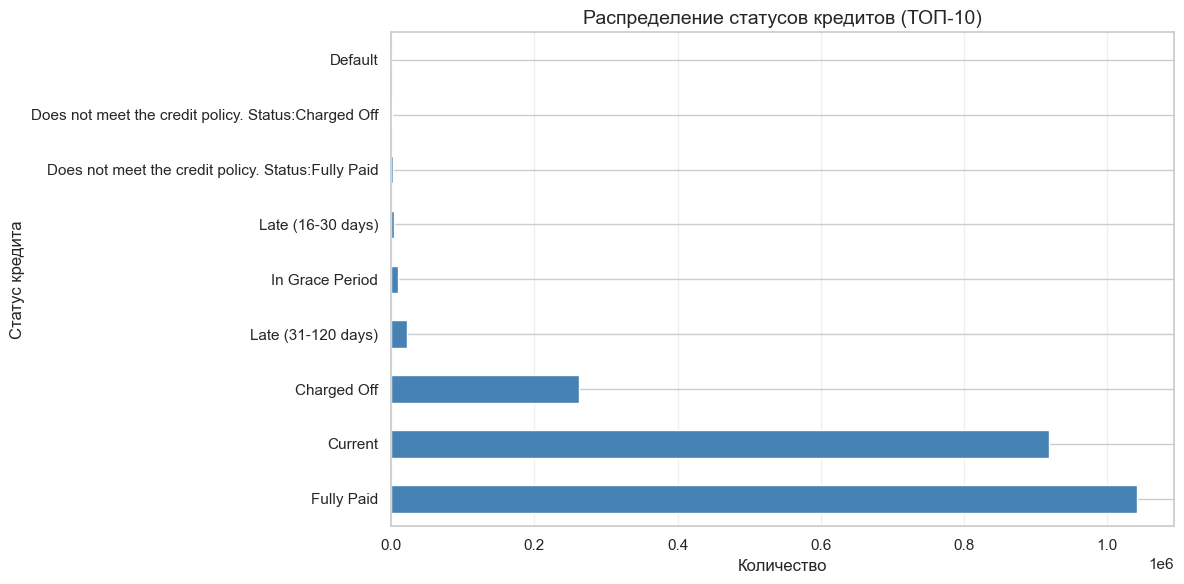

In [9]:
# Смотрим на оставшиеся столбцы с пропусками (после первой очистки)
print("=== Оставшиеся столбцы с пропусками ===")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
missing_pct = (remaining_missing / len(df) * 100).round(2)

missing_info = pd.DataFrame({
    'Пропусков': remaining_missing,
    '% пропусков': missing_pct
}).sort_values(by='% пропусков', ascending=False)

print(f"Всего столбцов с пропусками: {len(missing_info)}\n")
display(missing_info)

# Смотрим типы данных оставшихся столбцов
print("\n=== Типы данных в датасете ===")
print(df.dtypes.value_counts())

# Проверяем целевую переменную loan_status
if 'loan_status' in df.columns:
    print("\n=== Распределение loan_status ===")
    print(df['loan_status'].value_counts())
    
    # Визуализация
    plt.figure(figsize=(12, 6))
    df['loan_status'].value_counts().head(10).plot(kind='barh', color='steelblue')
    plt.title('Распределение статусов кредитов (ТОП-10)', fontsize=14)
    plt.xlabel('Количество')
    plt.ylabel('Статус кредита')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n️ Столбец 'loan_status' не найден!")
    print("Доступные столбцы со 'status' в названии:")
    status_cols = [col for col in df.columns if 'status' in col.lower()]
    print(status_cols)

Удаляем 5 столбцов с >50% пропусков:
['mths_since_last_delinq', 'next_pymnt_d', 'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq'] ...



C:\Users\user\AppData\Local\Temp\ipykernel_2800\4215049478.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


Заполнено медианой: annual_inc
Заполнено медианой: dti
Заполнено медианой: delinq_2yrs
Заполнено медианой: inq_last_6mths
Заполнено медианой: open_acc
Заполнено медианой: pub_rec
Заполнено медианой: revol_util
Заполнено медианой: total_acc
Заполнено медианой: collections_12_mths_ex_med
Заполнено медианой: acc_now_delinq
Заполнено медианой: tot_coll_amt
Заполнено медианой: tot_cur_bal
Заполнено медианой: open_acc_6m
Заполнено медианой: open_act_il
Заполнено медианой: open_il_12m
Заполнено медианой: open_il_24m
Заполнено медианой: mths_since_rcnt_il
Заполнено медианой: total_bal_il
Заполнено медианой: il_util
Заполнено медианой: open_rv_12m
Заполнено медианой: open_rv_24m
Заполнено медианой: max_bal_bc
Заполнено медианой: all_util
Заполнено медианой: total_rev_hi_lim
Заполнено медианой: inq_fi
Заполнено медианой: total_cu_tl
Заполнено медианой: inq_last_12m
Заполнено медианой: acc_open_past_24mths
Заполнено медианой: avg_cur_bal
Заполнено медианой: bc_open_to_buy
Заполнено медианой: bc_u

C:\Users\user\AppData\Local\Temp\ipykernel_2800\4215049478.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Заполнено модой: emp_title
Заполнено модой: emp_length
Заполнено модой: title
Заполнено модой: zip_code
Заполнено модой: earliest_cr_line
Заполнено модой: last_pymnt_d
Заполнено модой: last_credit_pull_d

✅ Обработка пропусков завершена
Осталось строк: 2260668, столбцов: 101
Пропусков в датасете: 0

=== Подготовка целевой переменной ===
Фильтруем датасет: оставляем только 'Fully Paid' и 'Charged Off'

Размер после фильтрации: 1303607 строк
Распределение целевой переменной:
target_default
0    1041952
1     261655
Name: count, dtype: int64

Доля дефолтов: 20.07%


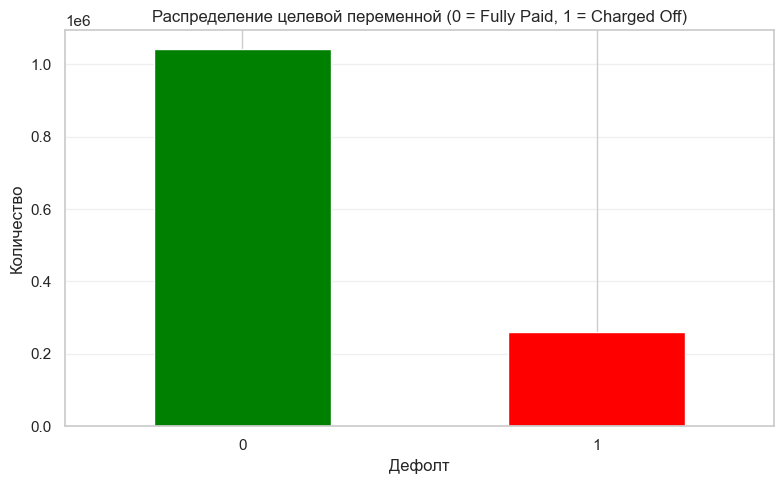

In [10]:
# === ШАГ 2: Обработка оставшихся пропусков ===

# 1. Удаляем столбцы с пропусками >50% (оставшиеся после первой очистки)
cols_to_drop_high_missing = []
for col in df.columns:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    if missing_pct > 50:
        cols_to_drop_high_missing.append(col)

print(f"Удаляем {len(cols_to_drop_high_missing)} столбцов с >50% пропусков:")
print(cols_to_drop_high_missing[:10], "...\n")

df.drop(columns=cols_to_drop_high_missing, inplace=True)

# 2. Для числовых столбцов с небольшим % пропусков заполняем медианой
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Заполнено медианой: {col}")

# 3. Для категориальных столбцов заполняем модой (наиболее частым значением)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Заполнено модой: {col}")

print(f"\n✅ Обработка пропусков завершена")
print(f"Осталось строк: {df.shape[0]}, столбцов: {df.shape[1]}")
print(f"Пропусков в датасете: {df.isnull().sum().sum()}")

# === ШАГ 3: Подготовка целевой переменной для ML ===

print("\n=== Подготовка целевой переменной ===")

# Создаем бинарную целевую переменную
# 1 = дефолт (Charged Off), 0 = возврат (Fully Paid)
# Current и остальные статусы удаляем для чистоты бинарной классификации

print("Фильтруем датасет: оставляем только 'Fully Paid' и 'Charged Off'")
df_binary = df[(df['loan_status'] == 'Fully Paid') | (df['loan_status'] == 'Charged Off')].copy()

# Создаем целевую переменную
df_binary['target_default'] = df_binary['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(f"\nРазмер после фильтрации: {df_binary.shape[0]} строк")
print(f"Распределение целевой переменной:")
print(df_binary['target_default'].value_counts())
print(f"\nДоля дефолтов: {df_binary['target_default'].mean()*100:.2f}%")

# Визуализация
plt.figure(figsize=(8, 5))
df_binary['target_default'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение целевой переменной (0 = Fully Paid, 1 = Charged Off)', fontsize=12)
plt.xlabel('Дефолт')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

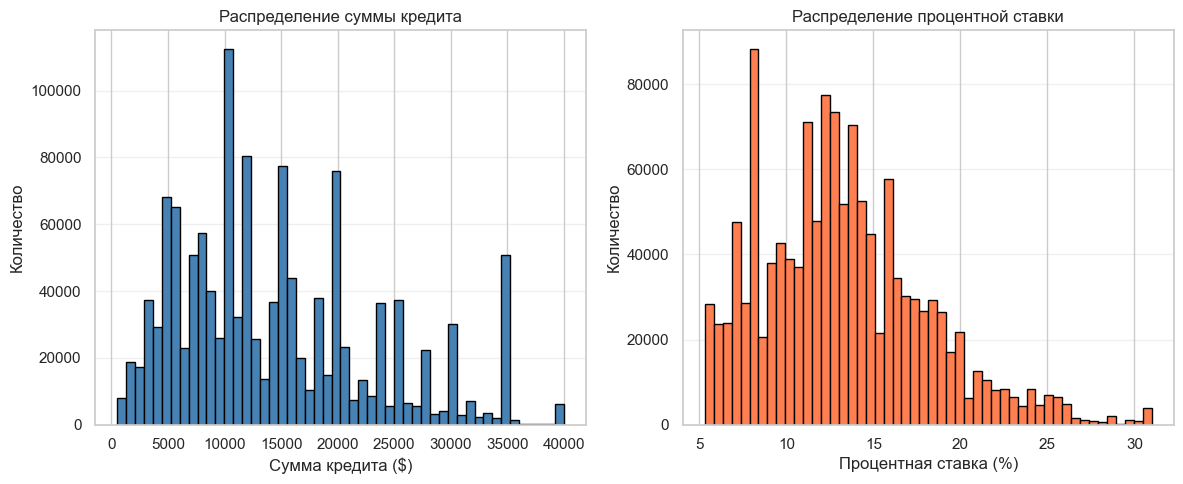

Статистика по сумме кредита:
count    1303607.00
mean       14416.81
std         8699.54
min          500.00
25%         8000.00
50%        12000.00
75%        20000.00
max        40000.00
Name: loan_amnt, dtype: float64

Статистика по процентной ставке:
count    1303607.00
mean          13.26
std            4.76
min            5.31
25%            9.75
50%           12.74
75%           15.99
max           30.99
Name: int_rate, dtype: float64


In [11]:
# === EDA: Анализ ключевых признаков ===

# 1. Распределение суммы кредита (loan_amnt)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_binary['loan_amnt'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Распределение суммы кредита', fontsize=12)
plt.xlabel('Сумма кредита ($)')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df_binary['int_rate'].hist(bins=50, color='coral', edgecolor='black')
plt.title('Распределение процентной ставки', fontsize=12)
plt.xlabel('Процентная ставка (%)')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Статистика по сумме кредита:")
print(df_binary['loan_amnt'].describe().round(2))
print(f"\nСтатистика по процентной ставке:")
print(df_binary['int_rate'].describe().round(2))

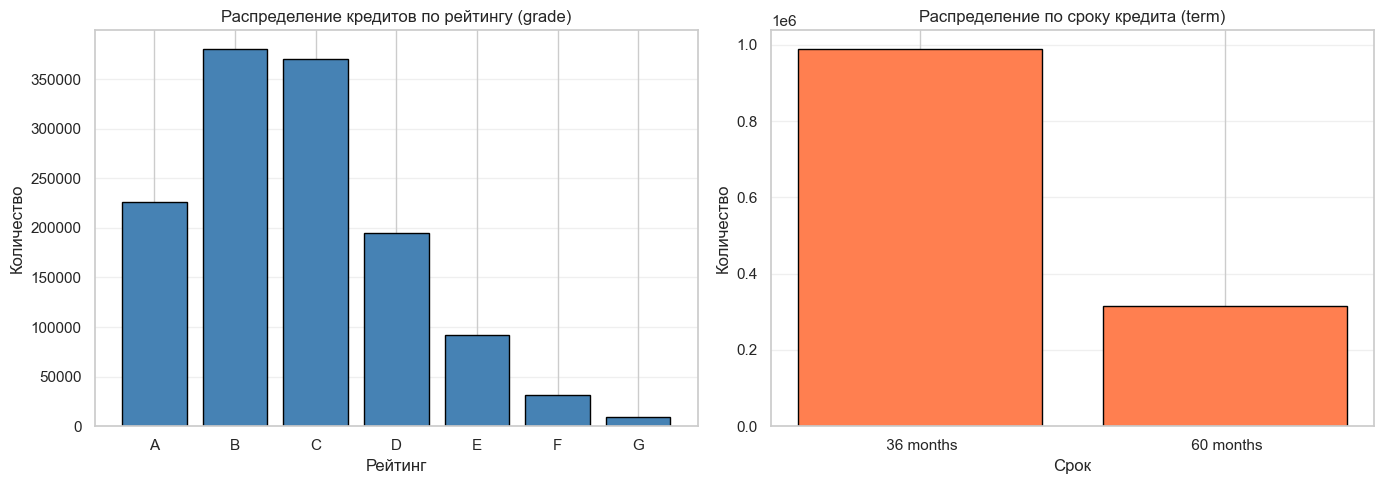

Распределение по grade:
grade
A    226243
B    380152
C    369928
D    195280
E     91570
F     31483
G      8951
Name: count, dtype: int64

Распределение по term:
term
36 months    988754
60 months    314853
Name: count, dtype: int64


In [12]:
# 2. Анализ по кредитному рейтингу (grade) и сроку кредита (term)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение по grade
grade_counts = df_binary['grade'].value_counts().sort_index()
axes[0].bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение кредитов по рейтингу (grade)', fontsize=12)
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', alpha=0.3)

# Распределение по term
term_counts = df_binary['term'].value_counts()
axes[1].bar(term_counts.index, term_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Распределение по сроку кредита (term)', fontsize=12)
axes[1].set_xlabel('Срок')
axes[1].set_ylabel('Количество')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Распределение по grade:")
print(grade_counts)
print("\nРаспределение по term:")
print(term_counts)

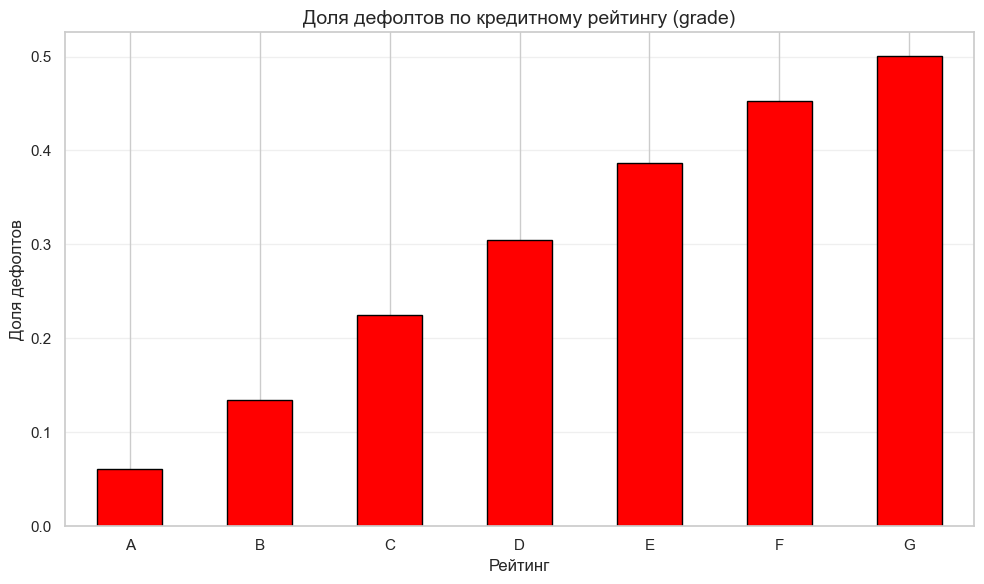

Доля дефолтов по grade:
grade
A     6.08
B    13.44
C    22.51
D    30.44
E    38.62
F    45.30
G    50.07
Name: target_default, dtype: float64

Вывод: Чем хуже рейтинг (от A к G), тем выше доля дефолтов


In [13]:
# 3. Доля дефолтов по кредитному рейтингу (grade)

# Группируем по grade и считаем долю дефолтов
default_by_grade = df_binary.groupby('grade')['target_default'].mean().sort_index()

plt.figure(figsize=(10, 6))
default_by_grade.plot(kind='bar', color='red', edgecolor='black')
plt.title('Доля дефолтов по кредитному рейтингу (grade)', fontsize=14)
plt.xlabel('Рейтинг')
plt.ylabel('Доля дефолтов')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Доля дефолтов по grade:")
print((default_by_grade * 100).round(2))
print("\nВывод: Чем хуже рейтинг (от A к G), тем выше доля дефолтов")

In [14]:
# Проверяем, какие столбцы связаны с кредитным рейтингом (FICO score)
print("=== Столбцы, содержащие 'fico' в названии ===")
fico_cols = [col for col in df_binary.columns if 'fico' in col.lower()]
print(fico_cols)

# Показываем все числовые столбцы для выбора
print("\n=== Все числовые столбцы в датасете ===")
numeric_cols = df_binary.select_dtypes(include=[np.number]).columns.tolist()
# Исключаем целевую переменную
numeric_cols = [col for col in numeric_cols if col != 'target_default']
print(f"Всего числовых столбцов: {len(numeric_cols)}")
print("\nПервые 30 числовых столбцов:")
for i, col in enumerate(numeric_cols[:30], 1):
    print(f"{i}. {col}")

# Выбираем ключевые столбцы для корреляции (те, что точно есть)
# Типичные важные признаки для кредитного скоринга:
key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 
                    'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']

# Проверяем, какие из них есть в датасете
available_cols = [col for col in key_numeric_cols if col in df_binary.columns]
print(f"\n=== Используемые столбцы для корреляции ===")
print(f"Доступно: {available_cols}")

# Если нужно, добавьте другие столбцы из списка выше
# Например: 'delinq_2yrs', 'mths_since_last_delinq', 'collections_12_mths_ex_med'

=== Столбцы, содержащие 'fico' в названии ===
[]

=== Все числовые столбцы в датасете ===
Всего числовых столбцов: 79

Первые 30 числовых столбцов:
1. loan_amnt
2. funded_amnt
3. funded_amnt_inv
4. int_rate
5. installment
6. annual_inc
7. dti
8. delinq_2yrs
9. inq_last_6mths
10. open_acc
11. pub_rec
12. revol_bal
13. revol_util
14. total_acc
15. out_prncp
16. out_prncp_inv
17. total_pymnt
18. total_pymnt_inv
19. total_rec_prncp
20. total_rec_int
21. total_rec_late_fee
22. recoveries
23. collection_recovery_fee
24. last_pymnt_amnt
25. collections_12_mths_ex_med
26. policy_code
27. acc_now_delinq
28. tot_coll_amt
29. tot_cur_bal
30. open_acc_6m

=== Используемые столбцы для корреляции ===
Доступно: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']


In [15]:
# Проверяем, какие dataframe у нас есть
print("=== Доступные переменные ===")
print([var for var in dir() if not var.startswith('_')])

# Проверяем, есть ли df_binary и target_default
if 'df_binary' in dir():
    print(f"\n✅ df_binary существует: {df_binary.shape}")
    print("\nСтолбцы в df_binary:")
    print(df_binary.columns.tolist())
    
    if 'target_default' not in df_binary.columns:
        print("\n⚠️ target_default не найден, создаём...")
        # Проверяем loan_status
        if 'loan_status' in df_binary.columns:
            print("\nУникальные значения loan_status:")
            print(df_binary['loan_status'].unique())
            
            # Создаем target_default
            df_binary['target_default'] = df_binary['loan_status'].map({
                'Fully Paid': 0,
                'Charged Off': 1
            })
            print("\n✅ Целевая переменная создана!")
            print(df_binary['target_default'].value_counts())
        else:
            print("\n❌ loan_status не найден в df_binary")
            # Ищем столбец со статусом
            status_cols = [col for col in df_binary.columns if 'status' in col.lower()]
            print(f"Найдены столбцы со 'status': {status_cols}")
    else:
        print("\n✅ target_default уже существует")
        print(df_binary['target_default'].value_counts())
else:
    print("\n❌ df_binary не найден. Возможно, нужно выполнить предыдущие ячейки.")
    print("Проверьте, какой dataframe содержит ваши данные:")
    print([var for var in dir() if not var.startswith('_') and 'df' in var.lower()])

=== Доступные переменные ===
['In', 'NamespaceMagics', 'Out', 'available_cols', 'axes', 'categorical_cols', 'col', 'collections', 'cols_to_drop', 'cols_to_drop_high_missing', 'cols_with_missing', 'default_by_grade', 'df', 'df_binary', 'dropped_cols', 'duplicates', 'existing_id_cols', 'exit', 'fico_cols', 'fig', 'get_ipython', 'grade_counts', 'i', 'id_columns', 'islice', 'json', 'kagglehub', 'key_numeric_cols', 'median_val', 'missing_df', 'missing_info', 'missing_pct', 'missing_percent', 'missing_values', 'mode_val', 'np', 'numeric_cols', 'open', 'path', 'pct', 'pd', 'plt', 'quit', 'remaining_missing', 'sns', 'sys', 'term_counts', 'total_missing']

✅ df_binary существует: (1303607, 102)

Столбцы в df_binary:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'de

=== Шаг 1: Создание целевой переменной ===
✅ Столбец 'loan_status' найден
Уникальные значения: ['Fully Paid' 'Charged Off']

✅ Целевая переменная создана!
Распределение:
target_default
0    1041952
1     261655
Name: count, dtype: int64
Доля дефолтов: 20.07%

=== Шаг 2: Проверка ===
Столбцы в df_binary (последние 10): ['pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'target_default']
'target_default' в столбцах: True

=== Шаг 3: Корреляционный анализ ===
Используемые столбцы: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']

=== Корреляция признаков с вероятностью дефолта ===
int_rate          0.258
dti               0.087
loan_amnt         0.065
inq_last_6mths    0.065
revol_util        0.061
open_acc          0.029
pub_rec           0.026
total_acc        -0.011
annual_inc       -

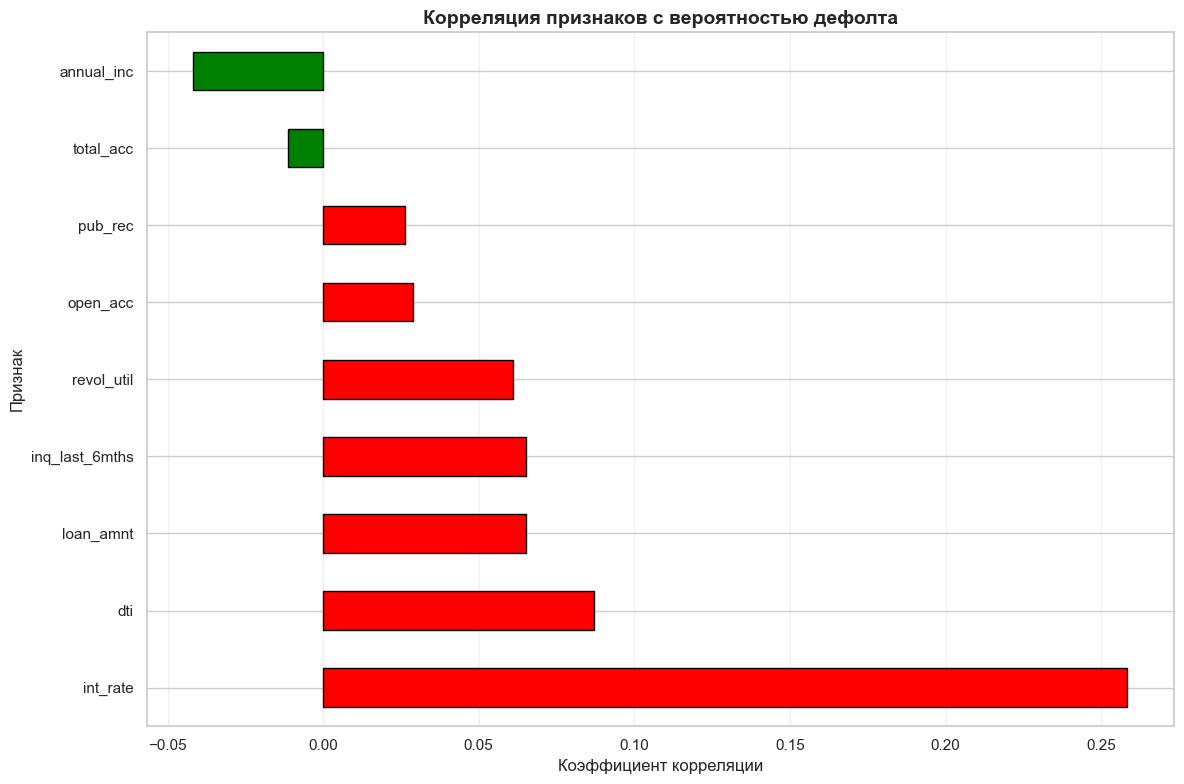


=== Ключевые выводы ===
🔴 Положительная корреляция → признак увеличивает риск дефолта
🟢 Отрицательная корреляция → признак снижает риск дефолта

📈 Факторы, УВЕЛИЧИВАЮЩИЕ риск дефолта (топ-3):
  • int_rate: 0.258
  • dti: 0.087
  • loan_amnt: 0.065

📉 Факторы, СНИЖАЮЩИЕ риск дефолта (топ-3):
  • pub_rec: 0.026
  • total_acc: -0.011
  • annual_inc: -0.042


In [16]:

# === ШАГ 1: Создаем целевую переменную ===
print("=== Шаг 1: Создание целевой переменной ===")

# Проверяем, есть ли loan_status
if 'loan_status' not in df_binary.columns:
    print("❌ Столбец 'loan_status' не найден!")
    print("Доступные столбцы со 'status':")
    status_cols = [col for col in df_binary.columns if 'status' in col.lower()]
    print(status_cols)
else:
    print("✅ Столбец 'loan_status' найден")
    print(f"Уникальные значения: {df_binary['loan_status'].unique()}")
    
    # Создаем target_default (даже если он уже был - перезапишем)
    df_binary['target_default'] = df_binary['loan_status'].map({
        'Fully Paid': 0,
        'Charged Off': 1
    })
    
    print(f"\n✅ Целевая переменная создана!")
    print(f"Распределение:")
    print(df_binary['target_default'].value_counts())
    print(f"Доля дефолтов: {df_binary['target_default'].mean()*100:.2f}%")

# === ШАГ 2: Проверяем, что столбец создан ===
print(f"\n=== Шаг 2: Проверка ===")
print(f"Столбцы в df_binary (последние 10): {df_binary.columns.tolist()[-10:]}")
print(f"'target_default' в столбцах: {'target_default' in df_binary.columns}")

# === ШАГ 3: Корреляционный анализ ===
if 'target_default' in df_binary.columns:
    print("\n=== Шаг 3: Корреляционный анализ ===")
    
    key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc',
                        'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']
    
    available_key_cols = [col for col in key_numeric_cols if col in df_binary.columns]
    print(f"Используемые столбцы: {available_key_cols}")
    
    # ИСПРАВЛЕНИЕ: включаем target_default в список столбцов для корреляции
    cols_for_corr = available_key_cols + ['target_default']
    
    # Считаем корреляцию
    correlation_with_target = df_binary[cols_for_corr].corr()['target_default'].sort_values(ascending=False)
    
    # Удаляем саму целевую переменную из результатов
    correlation_with_target = correlation_with_target.drop('target_default')
    
    print(f"\n=== Корреляция признаков с вероятностью дефолта ===")
    print(correlation_with_target.round(3))
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    colors = ['red' if x > 0 else 'green' for x in correlation_with_target]
    correlation_with_target.plot(kind='barh', color=colors, edgecolor='black')
    plt.title('Корреляция признаков с вероятностью дефолта', fontsize=14, fontweight='bold')
    plt.xlabel('Коэффициент корреляции', fontsize=12)
    plt.ylabel('Признак', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Выводы
    print("\n=== Ключевые выводы ===")
    print("🔴 Положительная корреляция → признак увеличивает риск дефолта")
    print("🟢 Отрицательная корреляция → признак снижает риск дефолта")
    
    print("\n📈 Факторы, УВЕЛИЧИВАЮЩИЕ риск дефолта (топ-3):")
    for col, val in correlation_with_target.head(3).items():
        print(f"  • {col}: {val:.3f}")
    
    print("\n📉 Факторы, СНИЖАЮЩИЕ риск дефолта (топ-3):")
    for col, val in correlation_with_target.tail(3).items():
        print(f"  • {col}: {val:.3f}")

else:
    print("❌ Не удалось создать target_default. Проверьте столбец loan_status.")

=== Шаг 1: Создаем/обновляем целевую переменную ===
✅ Целевая переменная создана/обновлена
Распределение: {0: 1041952, 1: 261655}

=== Шаг 2: Проверяем наличие столбца ===
'target_default' в df_binary: True
Тип данных: int64
Количество пропусков: 0

=== Шаг 3: Корреляционный анализ ===
Анализируем 9 признаков: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']

Столбцы во временном DataFrame: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths', 'target_default']
Размер: (1303607, 10)
Размер после удаления пропусков: (1303607, 10)

=== РЕЗУЛЬТАТ: Корреляция признаков с дефолтом ===
int_rate          0.258
dti               0.087
loan_amnt         0.065
inq_last_6mths    0.065
revol_util        0.061
open_acc          0.029
pub_rec           0.026
total_acc        -0.011
annual_inc       -0.042
Name: target_default, dtype: float64


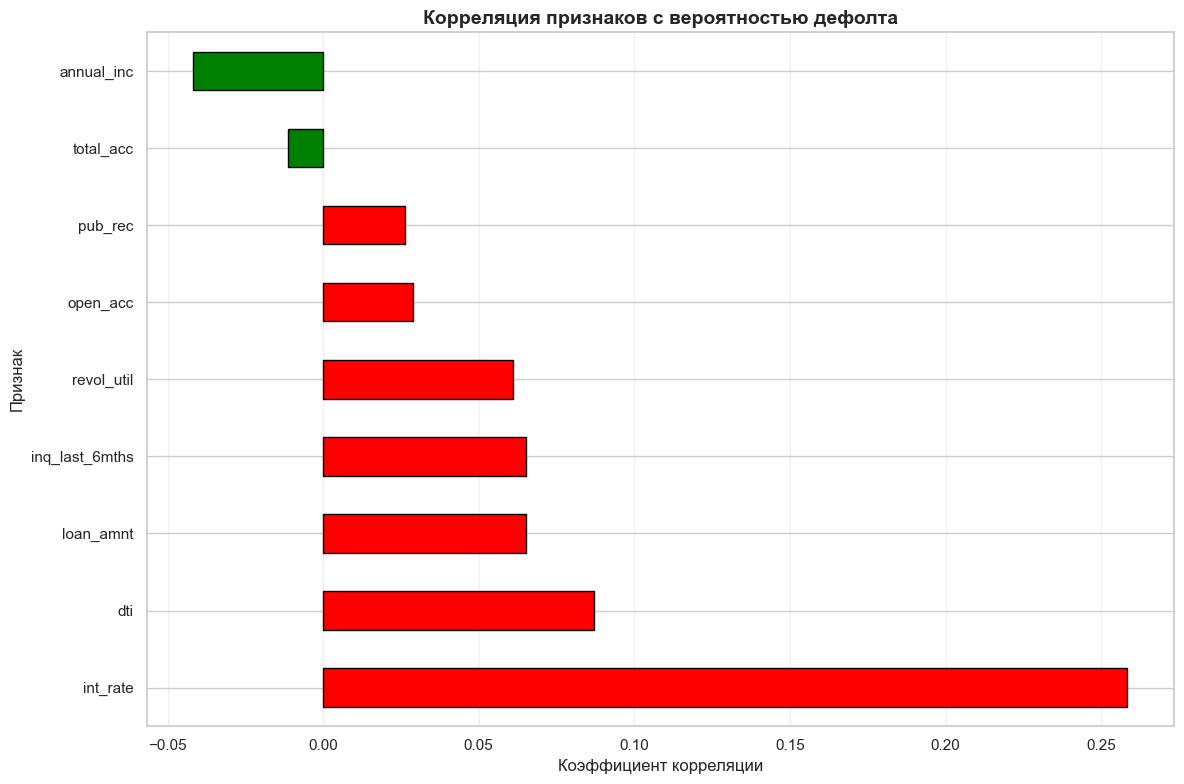


=== ИНТЕРПРЕТАЦИЯ ===
🔴 Положительная корреляция → признак увеличивает риск дефолта
🟢 Отрицательная корреляция → признак снижает риск дефолта

=== ТОП-3 ФАКТОРА РИСКА ===
Увеличивают риск дефолта:
  • int_rate: +0.258
  • dti: +0.087
  • loan_amnt: +0.065

Снижают риск дефолта:
  • pub_rec: +0.026
  • total_acc: -0.011
  • annual_inc: -0.042


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=== Шаг 1: Создаем/обновляем целевую переменную ===")
# Принудительно создаем target_default
df_binary['target_default'] = df_binary['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})
print(f"Целевая переменная создана/обновлена")
print(f"Распределение: {df_binary['target_default'].value_counts().to_dict()}")

print("\n=== Шаг 2: Проверяем наличие столбца ===")
print(f"'target_default' в df_binary: {'target_default' in df_binary.columns}")
print(f"Тип данных: {df_binary['target_default'].dtype}")
print(f"Количество пропусков: {df_binary['target_default'].isnull().sum()}")

print("\n=== Шаг 3: Корреляционный анализ ===")
# Выбираем признаки для анализа
key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 
                    'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']

# Фильтруем только существующие столбцы
available_key_cols = [col for col in key_numeric_cols if col in df_binary.columns]
print(f"Анализируем {len(available_key_cols)} признаков: {available_key_cols}")

# Создаем временный DataFrame для корреляции
temp_df = df_binary[available_key_cols + ['target_default']].copy()

# Проверяем, что target_default есть
print(f"\nСтолбцы во временном DataFrame: {temp_df.columns.tolist()}")
print(f"Размер: {temp_df.shape}")

# Удаляем пропуски если есть
temp_df = temp_df.dropna()
print(f"Размер после удаления пропусков: {temp_df.shape}")

# Считаем корреляцию
correlation_series = temp_df.corr()['target_default'].drop('target_default').sort_values(ascending=False)

print("\n=== РЕЗУЛЬТАТ: Корреляция признаков с дефолтом ===")
print(correlation_series.round(3))

# Визуализация
plt.figure(figsize=(12, 8))
colors = ['red' if x > 0 else 'green' for x in correlation_series]
correlation_series.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Корреляция признаков с вероятностью дефолта', fontsize=14, fontweight='bold')
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Интерпретация
print("\n=== ИНТЕРПРЕТАЦИЯ ===")
print("🔴 Положительная корреляция → признак увеличивает риск дефолта")
print("🟢 Отрицательная корреляция → признак снижает риск дефолта")

print("\n=== ТОП-3 ФАКТОРА РИСКА ===")
print("Увеличивают риск дефолта:")
for col, val in correlation_series.head(3).items():
    print(f"  • {col}: {val:+.3f}")

print("\nСнижают риск дефолта:")
for col, val in correlation_series.tail(3).items():
    print(f"  • {col}: {val:+.3f}")

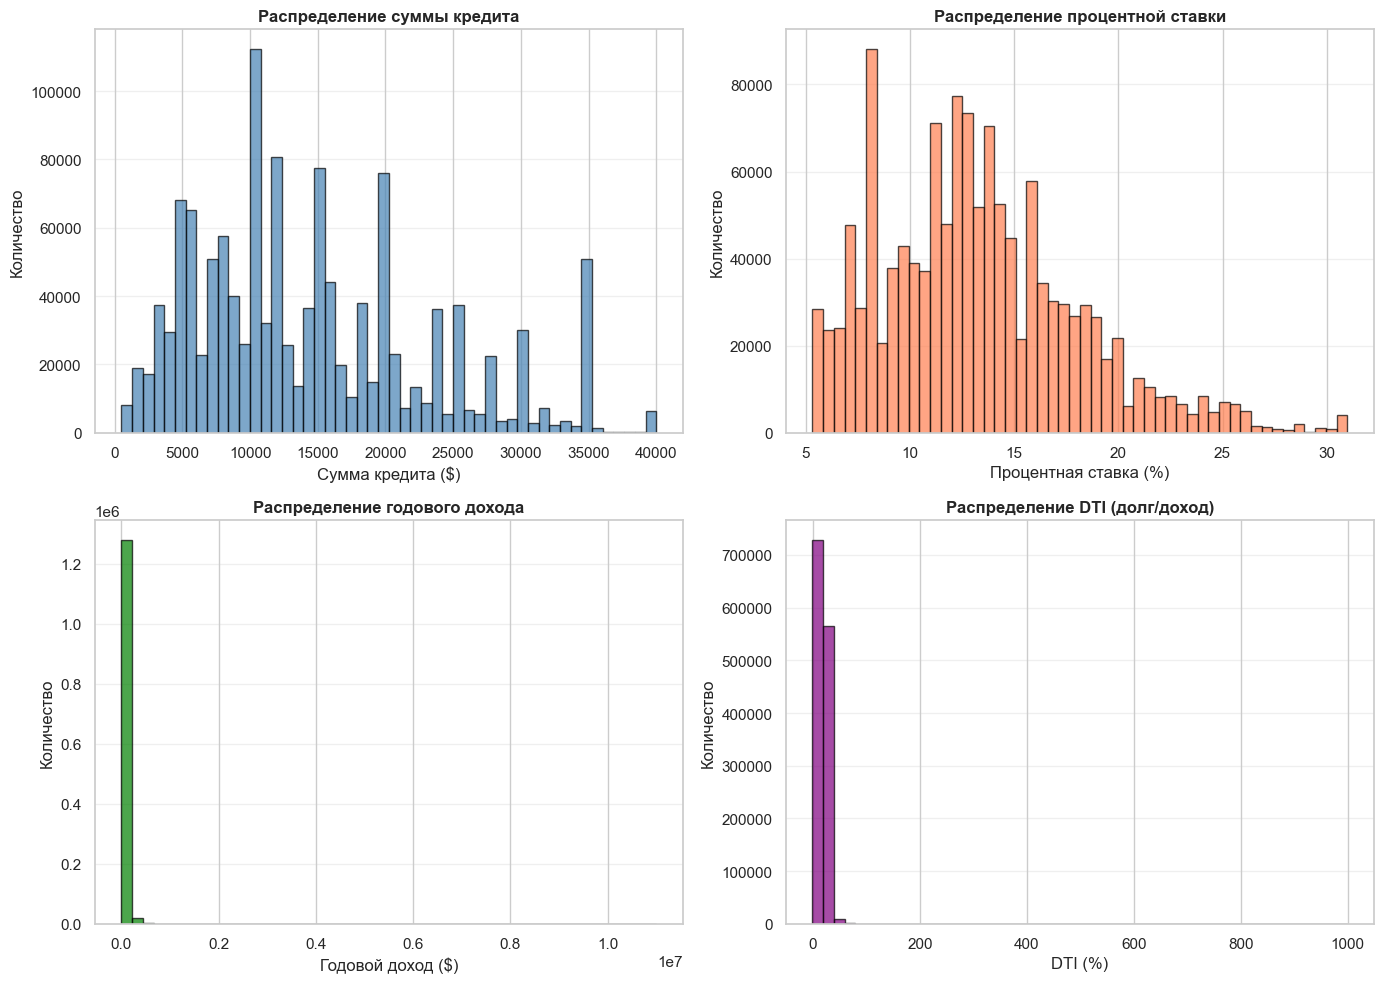

=== Описательная статистика ключевых признаков ===
        loan_amnt    int_rate   annual_inc         dti
count  1303607.00  1303607.00   1303607.00  1303607.00
mean     14416.81       13.26     76158.99       18.26
std       8699.54        4.76     70048.90       10.94
min        500.00        5.31         0.00       -1.00
25%       8000.00        9.75     45840.00       11.79
50%      12000.00       12.74     65000.00       17.61
75%      20000.00       15.99     90000.00       24.04
max      40000.00       30.99  10999200.00      999.00


In [18]:
# === EDA: Распределение ключевых признаков ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение суммы кредита
axes[0, 0].hist(df_binary['loan_amnt'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение суммы кредита', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Сумма кредита ($)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Распределение процентной ставки
axes[0, 1].hist(df_binary['int_rate'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение процентной ставки', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Процентная ставка (%)')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Распределение годового дохода
axes[1, 0].hist(df_binary['annual_inc'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение годового дохода', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Годовой доход ($)')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Распределение DTI (долговая нагрузка)
axes[1, 1].hist(df_binary['dti'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение DTI (долг/доход)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('DTI (%)')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("=== Описательная статистика ключевых признаков ===")
stats = df_binary[['loan_amnt', 'int_rate', 'annual_inc', 'dti']].describe().round(2)
print(stats)

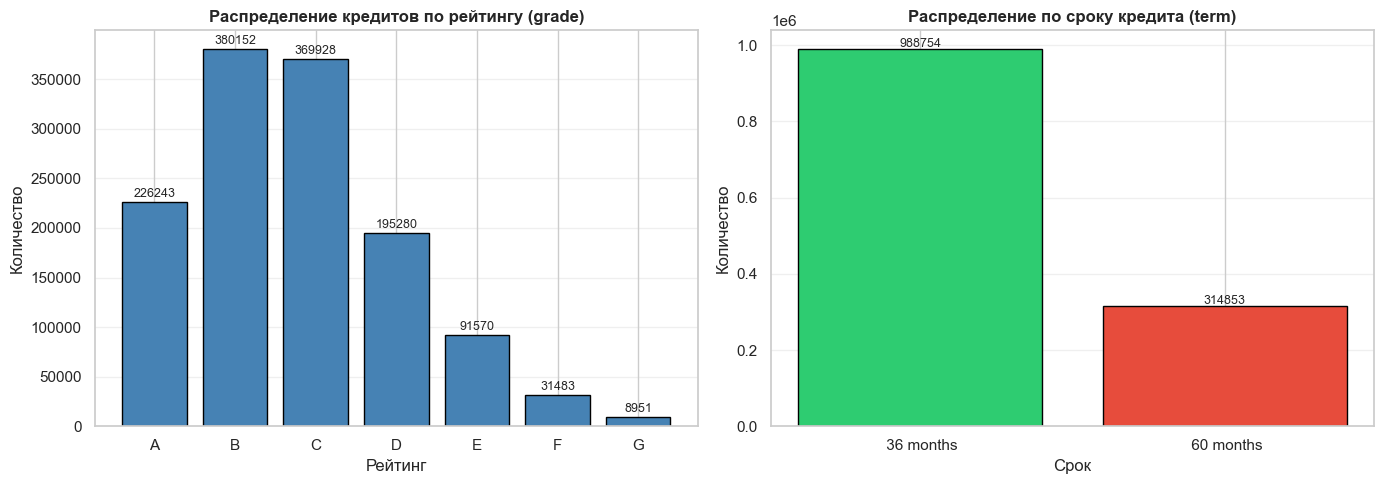

=== Распределение по grade ===
grade
A    226243
B    380152
C    369928
D    195280
E     91570
F     31483
G      8951
Name: count, dtype: int64

=== Распределение по term ===
term
36 months    988754
60 months    314853
Name: count, dtype: int64


In [19]:
# === EDA: Анализ по категориям ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Распределение по кредитному рейтингу (grade)
grade_counts = df_binary['grade'].value_counts().sort_index()
axes[0].bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение кредитов по рейтингу (grade)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 5000, str(v), ha='center', fontsize=9)

# 2. Распределение по сроку кредита (term)
term_counts = df_binary['term'].value_counts()
colors_term = ['#2ecc71' if '36' in str(t) else '#e74c3c' for t in term_counts.index]
axes[1].bar(term_counts.index, term_counts.values, color=colors_term, edgecolor='black')
axes[1].set_title('Распределение по сроку кредита (term)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Срок')
axes[1].set_ylabel('Количество')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(term_counts.values):
    axes[1].text(i, v + 5000, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Распределение по grade ===")
print(grade_counts)
print(f"\n=== Распределение по term ===")
print(term_counts)

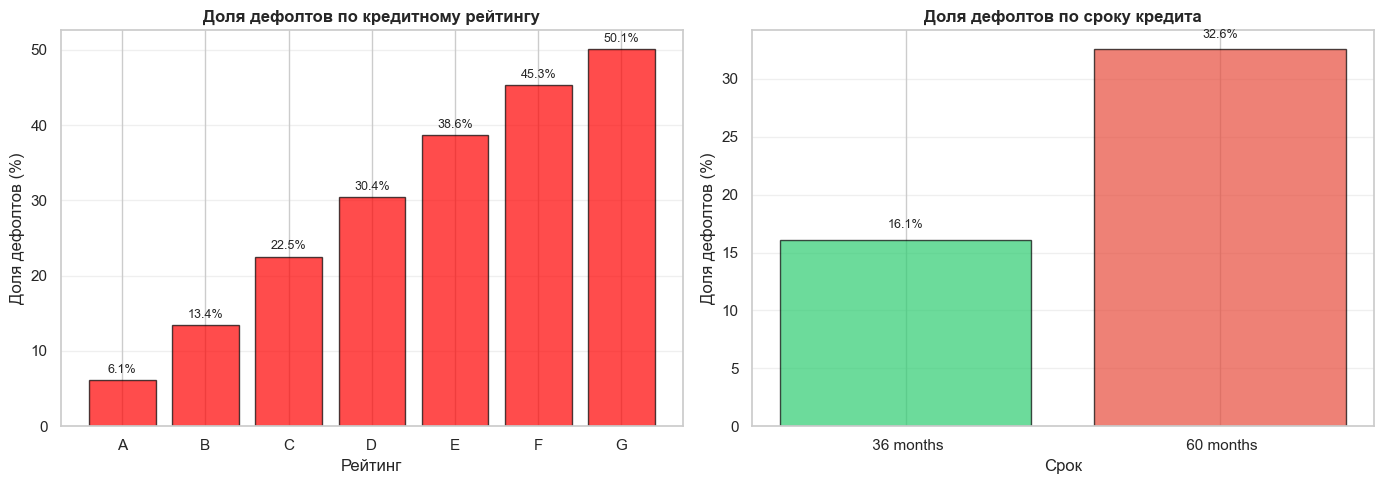

=== Доля дефолтов по grade ===
grade
A     6.08
B    13.44
C    22.51
D    30.44
E    38.62
F    45.30
G    50.07
Name: target_default, dtype: float64

=== Доля дефолтов по term ===
term
36 months    16.10
60 months    32.56
Name: target_default, dtype: float64

=== Ключевой вывод ===
Чем хуже кредитный рейтинг (от A к G), тем выше доля дефолтов
Кредиты на 60 месяцев имеют более высокий риск дефолта, чем на 36 месяцев


In [20]:
# === EDA: Доля дефолтов по категориям ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Доля дефолтов по кредитному рейтингу (grade)
default_by_grade = df_binary.groupby('grade')['target_default'].mean().sort_index()
axes[0].bar(default_by_grade.index, default_by_grade.values * 100, color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('Доля дефолтов по кредитному рейтингу', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Доля дефолтов (%)')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(default_by_grade.values):
    axes[0].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)

# 2. Доля дефолтов по сроку кредита (term)
default_by_term = df_binary.groupby('term')['target_default'].mean()
colors_term = ['#2ecc71' if '36' in str(t) else '#e74c3c' for t in default_by_term.index]
axes[1].bar(default_by_term.index, default_by_term.values * 100, color=colors_term, edgecolor='black', alpha=0.7)
axes[1].set_title('Доля дефолтов по сроку кредита', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Срок')
axes[1].set_ylabel('Доля дефолтов (%)')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(default_by_term.values):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Доля дефолтов по grade ===")
print((default_by_grade * 100).round(2))
print(f"\n=== Доля дефолтов по term ===")
print((default_by_term * 100).round(2))

print("\n=== Ключевой вывод ===")
print("Чем хуже кредитный рейтинг (от A к G), тем выше доля дефолтов")
print("Кредиты на 60 месяцев имеют более высокий риск дефолта, чем на 36 месяцев")

Столбцы с датами: []

=== Анализ по годам выдачи кредитов ===


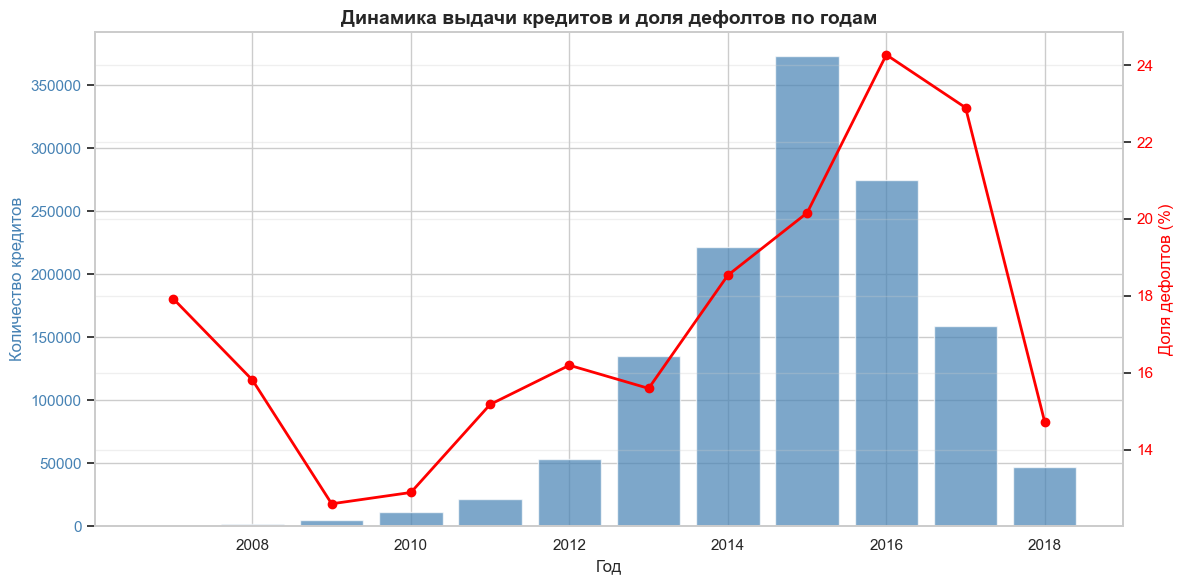


Количество кредитов по годам:
issue_year
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134793
2014    221468
2015    373412
2016    274699
2017    158900
2018     47182
dtype: int64

Доля дефолтов по годам (%):
issue_year
2007    17.93
2008    15.81
2009    12.60
2010    12.89
2011    15.18
2012    16.20
2013    15.60
2014    18.54
2015    20.16
2016    24.27
2017    22.89
2018    14.71
Name: target_default, dtype: float64


In [21]:
# === EDA: Временной анализ ===

# Проверяем, есть ли столбцы с датами
date_cols = [col for col in df_binary.columns if 'date' in col.lower()]
print(f"Столбцы с датами: {date_cols}")

if 'issue_d' in df_binary.columns:
    print("\n=== Анализ по годам выдачи кредитов ===")
    
    # Извлекаем год из issue_d
    df_binary['issue_year'] = pd.to_datetime(df_binary['issue_d'], format='%b-%Y', errors='coerce').dt.year
    
    # Группируем по году
    loans_by_year = df_binary.groupby('issue_year').size()
    default_by_year = df_binary.groupby('issue_year')['target_default'].mean() * 100
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Количество кредитов по годам
    color1 = 'steelblue'
    ax1.set_xlabel('Год', fontsize=12)
    ax1.set_ylabel('Количество кредитов', color=color1, fontsize=12)
    ax1.bar(loans_by_year.index, loans_by_year.values, color=color1, alpha=0.7, label='Количество кредитов')
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Доля дефолтов по годам
    ax2 = ax1.twinx()
    color2 = 'red'
    ax2.set_ylabel('Доля дефолтов (%)', color=color2, fontsize=12)
    ax2.plot(default_by_year.index, default_by_year.values, color=color2, marker='o', linewidth=2, label='Доля дефолтов')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    plt.title('Динамика выдачи кредитов и доля дефолтов по годам', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    print("\nКоличество кредитов по годам:")
    print(loans_by_year)
    print("\nДоля дефолтов по годам (%):")
    print(default_by_year.round(2))
    
else:
    print("Столбец 'issue_d' не найден. Временной анализ невозможен.")
    print("Доступные столбцы:", df_binary.columns.tolist()[:20])

Категориальных столбцов: 22
Примеры: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan']

Анализируем 6 категориальных признаков:
['grade', 'sub_grade', 'term', 'home_ownership', 'verification_status', 'loan_status']


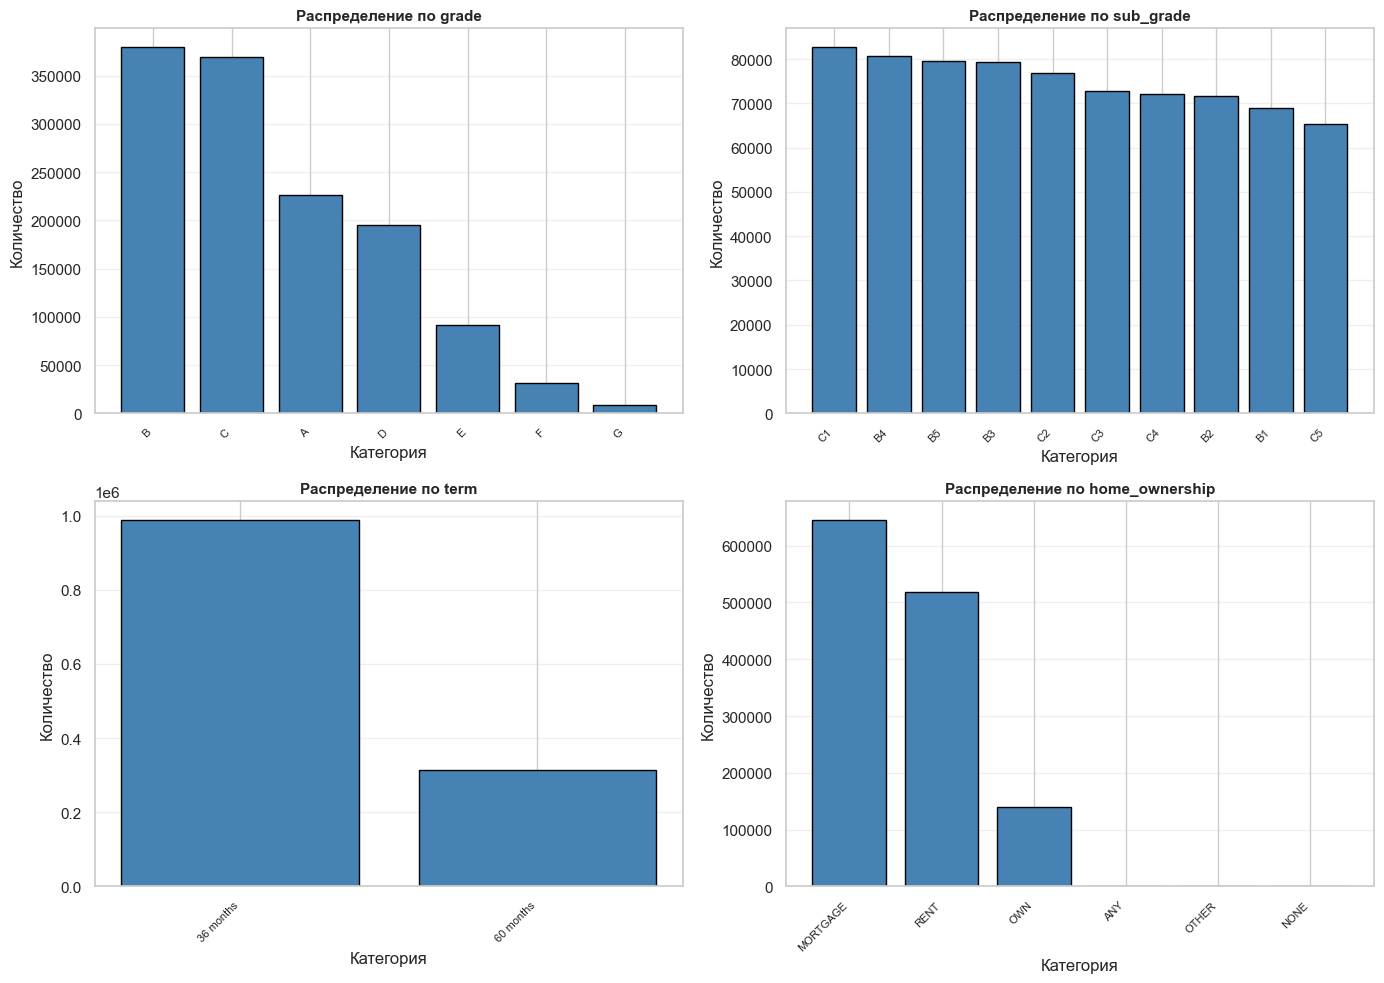


=== Статистика по категориям ===

grade:
grade
B    380152
C    369928
A    226243
D    195280
E     91570
Name: count, dtype: int64

sub_grade:
sub_grade
C1    82815
B4    80606
B5    79580
B3    79424
C2    76854
Name: count, dtype: int64

term:
term
36 months    988754
60 months    314853
Name: count, dtype: int64

home_ownership:
home_ownership
MORTGAGE    645496
RENT        517808
OWN         139844
ANY            267
OTHER          144
Name: count, dtype: int64


In [22]:
# === EDA: Анализ категориальных признаков ===

# Определяем категориальные столбцы
categorical_cols = df_binary.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальных столбцов: {len(categorical_cols)}")
print(f"Примеры: {categorical_cols[:10]}")

# Выбираем ключевые категориальные признаки для анализа
key_categorical = ['grade', 'sub_grade', 'term', 'home_ownership', 'verification_status', 'loan_status']
available_categorical = [col for col in key_categorical if col in df_binary.columns]

print(f"\nАнализируем {len(available_categorical)} категориальных признаков:")
print(available_categorical)

# Визуализация распределения по категориям
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(available_categorical[:4]):
    value_counts = df_binary[col].value_counts().head(10)
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Распределение по {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Категория')
    axes[idx].set_ylabel('Количество')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Статистика по категориям ===")
for col in available_categorical[:4]:
    print(f"\n{col}:")
    print(df_binary[col].value_counts().head(5))

In [23]:
# === FEATURE ENGINEERING: Создание новых признаков ===

print("=== Создание новых признаков ===")
initial_cols = df_binary.shape[1]
print(f"Исходное количество столбцов: {initial_cols}")

# 1. Отношение суммы кредита к годовому доходу (кредитная нагрузка)
df_binary['loan_to_income_ratio'] = df_binary['loan_amnt'] / df_binary['annual_inc']
print("✅ Создан: loan_to_income_ratio (кредитная нагрузка)")

# 2. Отношение платежа к доходу (платёжная нагрузка)
df_binary['payment_to_income_ratio'] = df_binary['installment'] / df_binary['annual_inc']
print("✅ Создан: payment_to_income_ratio (платёжная нагрузка)")

# 3. Количество открытых счетов на единицу дохода
df_binary['acc_per_income'] = df_binary['open_acc'] / (df_binary['annual_inc'] / 10000)
print("✅ Создан: acc_per_income (счета на $10k дохода)")

# 4. Использования кредитной линии (utilization rate)
if 'revol_util' in df_binary.columns:
    # revol_util уже есть, но можно создать бинарный признак высокой утилизации
    df_binary['high_revol_util'] = (df_binary['revol_util'] > 50).astype(int)
    print("✅ Создан: high_revol_util (высокая утилизация >50%)")

# 5. Возраст кредитной истории (если есть earliest_cr_line)
if 'earliest_cr_line' in df_binary.columns:
    try:
        df_binary['earliest_cr_line'] = pd.to_datetime(df_binary['earliest_cr_line'], errors='coerce')
        df_binary['credit_history_years'] = (pd.Timestamp.now() - df_binary['earliest_cr_line']).dt.days / 365.25
        print("✅ Создан: credit_history_years (длина кредитной истории)")
    except:
        print("⚠️ Не удалось создать credit_history_years")

# 6. Бинарные признаки риска
df_binary['high_dti'] = (df_binary['dti'] > 20).astype(int)  # Высокая долговая нагрузка
df_binary['high_int_rate'] = (df_binary['int_rate'] > df_binary['int_rate'].median()).astype(int)  # Высокая ставка
print("✅ Созданы: high_dti, high_int_rate (бинарные признаки риска)")

# 7. Количество публичных записей (банкротства, налоговые залоги)
pub_rec_cols = [col for col in df_binary.columns if 'pub_rec' in col.lower()]
if len(pub_rec_cols) > 0:
    df_binary['total_pub_records'] = df_binary[pub_rec_cols].sum(axis=1, skipna=True)
    print(f"✅ Создан: total_pub_records (сумма публичных записей)")

print(f"\n✅ Всего создано новых признаков: {df_binary.shape[1] - initial_cols}")
print(f"Итого столбцов: {df_binary.shape[1]}")

# Проверяем новые признаки
print("\n=== Статистика новых признаков ===")
new_cols = ['loan_to_income_ratio', 'payment_to_income_ratio', 'acc_per_income', 'high_dti', 'high_int_rate']
existing_new_cols = [col for col in new_cols if col in df_binary.columns]
print(df_binary[existing_new_cols].describe().round(3))

=== Создание новых признаков ===
Исходное количество столбцов: 103
✅ Создан: loan_to_income_ratio (кредитная нагрузка)
✅ Создан: payment_to_income_ratio (платёжная нагрузка)
✅ Создан: acc_per_income (счета на $10k дохода)
✅ Создан: high_revol_util (высокая утилизация >50%)
✅ Создан: credit_history_years (длина кредитной истории)


C:\Users\user\AppData\Local\Temp\ipykernel_2800\723904944.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_binary['earliest_cr_line'] = pd.to_datetime(df_binary['earliest_cr_line'], errors='coerce')


✅ Созданы: high_dti, high_int_rate (бинарные признаки риска)
✅ Создан: total_pub_records (сумма публичных записей)

✅ Всего создано новых признаков: 8
Итого столбцов: 111

=== Статистика новых признаков ===
       loan_to_income_ratio  payment_to_income_ratio  acc_per_income  \
count           1303607.000              1303607.000     1303607.000   
mean                    inf                      inf             inf   
std                     NaN                      NaN             NaN   
min                   0.000                    0.000           0.000   
25%                   0.125                    0.004           1.087   
50%                   0.200                    0.006           1.633   
75%                   0.291                    0.009           2.407   
max                     inf                      inf             inf   

          high_dti  high_int_rate  
count  1303607.000    1303607.000  
mean         0.398          0.499  
std          0.490          0.500  


=== Корреляция новых признаков с дефолтом ===
loan_to_income_ratio: -0.0002
payment_to_income_ratio: -0.0003
high_dti: +0.0940
high_int_rate: +0.2097


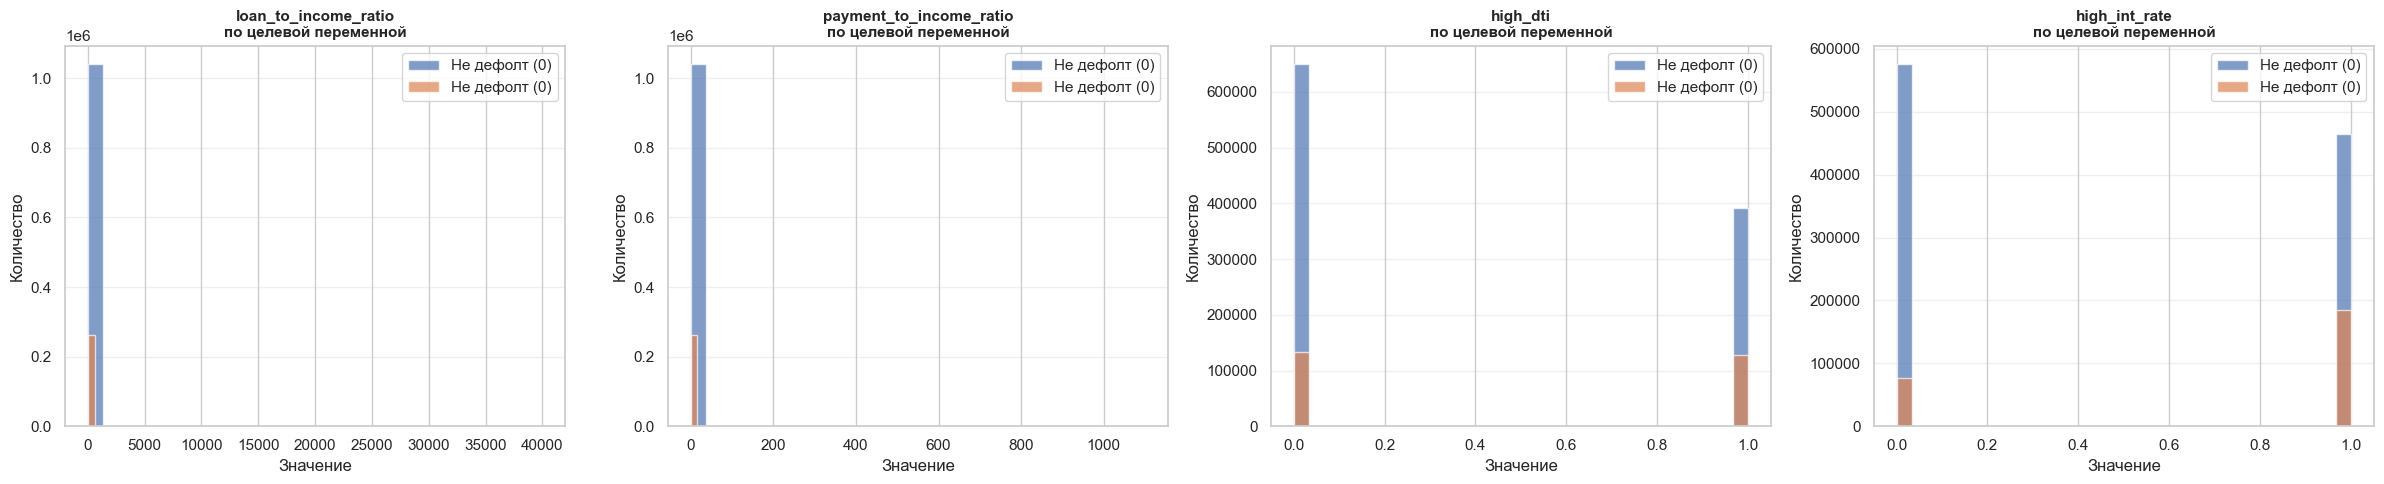


=== Вывод ===
Новые признаки показывают разную степень связи с дефолтом.
Признаки с высокой корреляцией будут полезны для ML-модели.


In [24]:
# === Анализ связи новых признаков с дефолтом ===

new_features = ['loan_to_income_ratio', 'payment_to_income_ratio', 'high_dti', 'high_int_rate']
available_new_features = [col for col in new_features if col in df_binary.columns]

print("=== Корреляция новых признаков с дефолтом ===")
for col in available_new_features:
    # Заменяем inf на NaN перед вычислением корреляции
    col_clean = df_binary[col].replace([np.inf, -np.inf], np.nan)
    corr = col_clean.corr(df_binary['target_default'])
    print(f"{col}: {corr:+.4f}")

# Визуализация
if len(available_new_features) > 0:
    fig, axes = plt.subplots(1, len(available_new_features), figsize=(6*len(available_new_features), 5))
    if len(available_new_features) == 1:
        axes = [axes]

    for idx, col in enumerate(available_new_features):
        # Группируем по целевой переменной и смотрим распределение
        # Заменяем inf на NaN для корректного построения гистограммы
        df_clean = df_binary.copy()
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        
        # Удаляем строки с NaN для текущего столбца
        df_clean = df_clean.dropna(subset=[col])
        
        df_clean.groupby('target_default')[col].hist(
            alpha=0.7, 
            bins=30, 
            ax=axes[idx],
            label=['Не дефолт (0)', 'Дефолт (1)']
        )
        axes[idx].set_title(f'{col}\nпо целевой переменной', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Значение')
        axes[idx].set_ylabel('Количество')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n=== Вывод ===")
print("Новые признаки показывают разную степень связи с дефолтом.")
print("Признаки с высокой корреляцией будут полезны для ML-модели.")

In [25]:
# === СОЗДАНИЕ ОБЛЕГЧЁННОЙ ВЕРСИИ ДЛЯ POWER BI ===

print("=== Подготовка данных для Power BI ===")

# 1. Выбираем важные колонки
cols_for_pbi = [
    # Целевая переменная
    'target_default',
    
    # Основные финансовые показатели
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    
    # Кредитные характеристики
    'grade',
    'sub_grade',
    'term',
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state',
    
    # Кредитная история
    'open_acc',
    'total_acc',
    'pub_rec',
    'revol_util',
    'inq_last_6mths',
    'delinq_2yrs',
    'revol_bal',
    
    # Временные
    'issue_d',
    
    # Новые признаки
    'high_dti',
    'high_int_rate',
    'loan_to_income_ratio'
]

# Проверяем, какие колонки есть в df_binary
available_cols = [col for col in cols_for_pbi if col in df_binary.columns]
missing_cols = [col for col in cols_for_pbi if col not in df_binary.columns]

print(f"✅ Используем {len(available_cols)} колонок из {len(cols_for_pbi)} запрошенных")
if missing_cols:
    print(f"⚠️ Отсутствуют: {missing_cols}")

# 2. Создаём DataFrame для Power BI
df_pbi = df_binary[available_cols].copy()

# 3. Удаляем строки с критическими пропусками (если есть)
df_pbi = df_pbi.dropna(subset=['loan_amnt', 'int_rate', 'annual_inc', 'dti'])

# 4. Удаляем экстремальные выбросы (для лучшей работы Power BI)
# Оставляем 99% данных, отсекаем 0.5% с каждого хвоста
for col in ['loan_amnt', 'annual_inc', 'dti']:
    if col in df_pbi.columns:
        lower = df_pbi[col].quantile(0.005)
        upper = df_pbi[col].quantile(0.995)
        df_pbi = df_pbi[(df_pbi[col] >= lower) & (df_pbi[col] <= upper)]

print(f"✅ Размер после очистки: {df_pbi.shape[0]:,} строк, {df_pbi.shape[1]} столбцов")

# 5. Переименовываем колонки на русский (для удобства в Power BI)
rename_dict = {
    'target_default': 'Дефолт',
    'loan_amnt': 'Сумма_займа',
    'int_rate': 'Процентная_ставка',
    'installment': 'Ежемесячный_платеж',
    'annual_inc': 'Годовой_доход',
    'dti': 'Долговая_нагрузка_DTI',
    'grade': 'Рейтинг_grade',
    'sub_grade': 'Рейтинг_sub_grade',
    'term': 'Срок_кредита',
    'home_ownership': 'Тип_жилья',
    'verification_status': 'Статус_проверки',
    'purpose': 'Цель_кредита',
    'addr_state': 'Штат',
    'open_acc': 'Открытых_счетов',
    'total_acc': 'Всего_счетов',
    'pub_rec': 'Публичные_записи',
    'revol_util': 'Использование_лимита',
    'inq_last_6mths': 'Запросов_за_6_мес',
    'delinq_2yrs': 'Просрочек_за_2_года',
    'revol_bal': 'Оборотный_баланс',
    'issue_d': 'Дата_выдачи',
    'high_dti': 'Высокая_долговая_нагрузка',
    'high_int_rate': 'Высокая_ставка',
    'loan_to_income_ratio': 'Займ_к_доходу'
}

# Переименовываем только существующие колонки
for old, new in rename_dict.items():
    if old in df_pbi.columns:
        df_pbi = df_pbi.rename(columns={old: new})

print(f"\n=== Сохранение файла ===")

# 6. Сохраняем в CSV с оптимизацией
output_file = 'loan_data_for_powerbi.csv'
df_pbi.to_csv(output_file, index=False, encoding='utf-8-sig')

# 7. Информация о файле
import os
file_size = os.path.getsize(output_file) / (1024 * 1024)  # в МБ
print(f"✅ Файл сохранён: {output_file}")
print(f"📦 Размер файла: {file_size:.2f} МБ")
print(f"📊 Строк: {df_pbi.shape[0]:,}")
print(f"📋 Колонок: {df_pbi.shape[1]}")

print("\n=== Первые 5 строк ===")
print(df_pbi.head())

=== Подготовка данных для Power BI ===
✅ Используем 24 колонок из 24 запрошенных
✅ Размер после очистки: 0 строк, 24 столбцов

=== Сохранение файла ===
✅ Файл сохранён: loan_data_for_powerbi.csv
📦 Размер файла: 0.00 МБ
📊 Строк: 0
📋 Колонок: 24

=== Первые 5 строк ===
Empty DataFrame
Columns: [Дефолт, Сумма_займа, Процентная_ставка, Ежемесячный_платеж, Годовой_доход, Долговая_нагрузка_DTI, Рейтинг_grade, Рейтинг_sub_grade, Срок_кредита, Тип_жилья, Статус_проверки, Цель_кредита, Штат, Открытых_счетов, Всего_счетов, Публичные_записи, Использование_лимита, Запросов_за_6_мес, Просрочек_за_2_года, Оборотный_баланс, Дата_выдачи, Высокая_долговая_нагрузка, Высокая_ставка, Займ_к_доходу]
Index: []

[0 rows x 24 columns]


In [26]:
# === СОЗДАНИЕ ОБЛЕГЧЁННОЙ ВЕРСИИ ДЛЯ POWER BI (БЕЗ УДАЛЕНИЯ ВЫБРОСОВ) ===

print("=== Подготовка данных для Power BI (полная версия) ===")

# 1. Выбираем важные колонки
cols_for_pbi = [
    'target_default',
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'grade',
    'sub_grade',
    'term',
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state',
    'open_acc',
    'total_acc',
    'pub_rec',
    'revol_util',
    'inq_last_6mths',
    'delinq_2yrs',
    'revol_bal',
    'issue_d',
    'high_dti',
    'high_int_rate',
    'loan_to_income_ratio'
]

# Проверяем, какие колонки есть в df_binary
available_cols = [col for col in cols_for_pbi if col in df_binary.columns]

print(f"✅ Используем {len(available_cols)} колонок из {len(cols_for_pbi)} запрошенных")

# 2. Создаём DataFrame для Power BI (БЕЗ УДАЛЕНИЯ ВЫБРОСОВ)
df_pbi_full = df_binary[available_cols].copy()

# 3. Удаляем только строки с критическими пропусками
df_pbi_full = df_pbi_full.dropna(subset=['loan_amnt', 'int_rate', 'annual_inc', 'dti'])

print(f"✅ Размер полного датасета: {df_pbi_full.shape[0]:,} строк, {df_pbi_full.shape[1]} столбцов")

# 4. Переименовываем колонки на русский
rename_dict = {
    'target_default': 'Дефолт',
    'loan_amnt': 'Сумма_займа',
    'int_rate': 'Процентная_ставка',
    'installment': 'Ежемесячный_платеж',
    'annual_inc': 'Годовой_доход',
    'dti': 'Долговая_нагрузка_DTI',
    'grade': 'Рейтинг_grade',
    'sub_grade': 'Рейтинг_sub_grade',
    'term': 'Срок_кредита',
    'home_ownership': 'Тип_жилья',
    'verification_status': 'Статус_проверки',
    'purpose': 'Цель_кредита',
    'addr_state': 'Штат',
    'open_acc': 'Открытых_счетов',
    'total_acc': 'Всего_счетов',
    'pub_rec': 'Публичные_записи',
    'revol_util': 'Использование_лимита',
    'inq_last_6mths': 'Запросов_за_6_мес',
    'delinq_2yrs': 'Просрочек_за_2_года',
    'revol_bal': 'Оборотный_баланс',
    'issue_d': 'Дата_выдачи',
    'high_dti': 'Высокая_долговая_нагрузка',
    'high_int_rate': 'Высокая_ставка',
    'loan_to_income_ratio': 'Займ_к_доходу'
}

for old, new in rename_dict.items():
    if old in df_pbi_full.columns:
        df_pbi_full = df_pbi_full.rename(columns={old: new})

# 5. Сохраняем полный файл
output_file = 'loan_data_for_powerbi_FULL.csv'
df_pbi_full.to_csv(output_file, index=False, encoding='utf-8-sig')

import os
file_size = os.path.getsize(output_file) / (1024 * 1024)
print(f"✅ Файл сохранён: {output_file}")
print(f"📦 Размер файла: {file_size:.2f} МБ")
print(f"📊 Строк: {df_pbi_full.shape[0]:,}")
print(f"📋 Колонок: {df_pbi_full.shape[1]}")

print("\n=== Проверка итоговых цифр ===")
print(f"Кол-во кредитов: {df_pbi_full.shape[0]:,}")
print(f"Кол-во дефолтов: {df_pbi_full[df_pbi_full['Дефолт'] == 1].shape[0]:,}")
print(f"Доля дефолтов: {df_pbi_full[df_pbi_full['Дефолт'] == 1].shape[0] / df_pbi_full.shape[0] * 100:.2f}%")

=== Подготовка данных для Power BI (полная версия) ===
✅ Используем 24 колонок из 24 запрошенных
✅ Размер полного датасета: 1,303,607 строк, 24 столбцов
✅ Файл сохранён: loan_data_for_powerbi_FULL.csv
📦 Размер файла: 188.00 МБ
📊 Строк: 1,303,607
📋 Колонок: 24

=== Проверка итоговых цифр ===
Кол-во кредитов: 1,303,607
Кол-во дефолтов: 261,655
Доля дефолтов: 20.07%


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаём структуру папок
os.makedirs('Приложения/Графические_материалы', exist_ok=True)
os.makedirs('Приложения/Файлы_результатов', exist_ok=True)
os.makedirs('Приложения/Инструментарий', exist_ok=True)

print("=== СОХРАНЕНИЕ ГРАФИЧЕСКИХ МАТЕРИАЛОВ ===")

# 2. График 1-2: Сумма кредита и процентная ставка
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_binary['loan_amnt'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение суммы кредита', fontsize=12)
axes[0].set_xlabel('Сумма кредита ($)')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df_binary['int_rate'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Распределение процентной ставки', fontsize=12)
axes[1].set_xlabel('Процентная ставка (%)')
axes[1].set_ylabel('Количество')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart1_loan_amnt_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.savefig('Приложения/Графические_материалы/chart2_int_rate_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart1_loan_amnt_distribution.png")
print("✅ chart2_int_rate_distribution.png")


# 3. Графики 3-4: Годовой доход и DTI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_binary['annual_inc'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение годового дохода', fontsize=12)
axes[0].set_xlabel('Годовой доход ($)')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df_binary['dti'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение DTI (долг/доход)', fontsize=12)
axes[1].set_xlabel('DTI (%)')
axes[1].set_ylabel('Количество')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart3_annual_inc_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.savefig('Приложения/Графические_материалы/chart4_dti_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart3_annual_inc_distribution.png")
print("✅ chart4_dti_distribution.png")


# 4. График 5: Распределение по grade
plt.figure(figsize=(10, 6))
grade_counts = df_binary['grade'].value_counts().sort_index()
plt.bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='black')
plt.title('Распределение кредитов по рейтингу (grade)', fontsize=13, fontweight='bold')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart5_grade_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart5_grade_distribution.png")


# 5. График 6: Распределение по term
plt.figure(figsize=(8, 6))
term_counts = df_binary['term'].value_counts()
plt.bar(term_counts.index, term_counts.values, color='coral', edgecolor='black')
plt.title('Распределение по сроку кредита (term)', fontsize=13, fontweight='bold')
plt.xlabel('Срок')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart6_term_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart6_term_distribution.png")


# 6. График 7: Доля дефолтов по grade
plt.figure(figsize=(10, 6))
default_by_grade = df_binary.groupby('grade')['target_default'].mean().sort_index()
plt.bar(default_by_grade.index, default_by_grade.values, color='red', edgecolor='black')
plt.title('Доля дефолтов по кредитному рейтингу (grade)', fontsize=13, fontweight='bold')
plt.xlabel('Рейтинг')
plt.ylabel('Доля дефолтов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart7_default_by_grade.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart7_default_by_grade.png")


# 7. График 8: Доля дефолтов по term
plt.figure(figsize=(8, 6))
default_by_term = df_binary.groupby('term')['target_default'].mean()
colors_term = ['#2ecc71' if '36' in str(t) else '#e74c3c' for t in default_by_term.index]
plt.bar(default_by_term.index, default_by_term.values, color=colors_term, edgecolor='black')
plt.title('Доля дефолтов по сроку кредита', fontsize=13, fontweight='bold')
plt.xlabel('Срок')
plt.ylabel('Доля дефолтов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart8_default_by_term.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart8_default_by_term.png")


# 8. График 9: Динамика по годам
if 'issue_year' not in df_binary.columns:
    df_binary['issue_year'] = pd.to_datetime(df_binary['issue_d'], format='%b-%Y', errors='coerce').dt.year

loans_by_year = df_binary.groupby('issue_year').size()
default_by_year = df_binary.groupby('issue_year')['target_default'].mean() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
color1 = 'steelblue'
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Количество кредитов', color=color1, fontsize=12)
ax1.bar(loans_by_year.index, loans_by_year.values, color=color1, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('Доля дефолтов (%)', color=color2, fontsize=12)
ax2.plot(default_by_year.index, default_by_year.values, color=color2, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Динамика выдачи кредитов и доля дефолтов по годам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart9_dynamics_by_year.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart9_dynamics_by_year.png")


# 9. График 10: Корреляция исходных признаков с дефолтом
key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 
                    'total_acc', 'pub_rec', 'revol_util', 'inq_last_6mths']
available_key_cols = [col for col in key_numeric_cols if col in df_binary.columns]
correlation_series = df_binary[available_key_cols + ['target_default']].corr()['target_default'].drop('target_default').sort_values()

plt.figure(figsize=(10, 7))
colors = ['red' if x > 0 else 'green' for x in correlation_series]
correlation_series.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Корреляция признаков с вероятностью дефолта', fontsize=13, fontweight='bold')
plt.xlabel('Коэффициент корреляции')
plt.ylabel('Признак')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Приложения/Графические_материалы/chart10_correlation_target.png', 
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ chart10_correlation_target.png")


# 10. График 11: Корреляция созданных признаков с дефолтом
new_features = ['high_int_rate', 'loan_to_income_ratio', 'payment_to_income_ratio', 'acc_per_income']
available_new = [col for col in new_features if col in df_binary.columns]

if len(available_new) > 0:
    corr_new = {}
    for col in available_new:
        col_clean = df_binary[col].replace([np.inf, -np.inf], np.nan)
        corr_new[col] = col_clean.corr(df_binary['target_default'])
    
    corr_series_new = pd.Series(corr_new).sort_values()
    
    plt.figure(figsize=(10, 6))
    colors_new = ['red' if x > 0 else 'green' for x in corr_series_new]
    corr_series_new.plot(kind='barh', color=colors_new, edgecolor='black')
    plt.title('Корреляция созданных признаков с дефолтом', fontsize=13, fontweight='bold')
    plt.xlabel('Коэффициент корреляции')
    plt.ylabel('Признак')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('Приложения/Графические_материалы/chart11_new_features_correlation.png', 
                dpi=150, bbox_inches='tight')
    plt.close()
    print("✅ chart11_new_features_correlation.png")


print("\n=== СОХРАНЕНИЕ ФАЙЛОВ РЕЗУЛЬТАТОВ ===")

# 11. structure_default_by_grade.csv
default_by_grade_df = df_binary.groupby('grade')['target_default'].mean().reset_index()
default_by_grade_df.columns = ['Рейтинг', 'Доля_дефолтов']
default_by_grade_df.to_csv('Приложения/Файлы_результатов/structure_default_by_grade.csv', 
                            index=False, encoding='utf-8-sig')
print("✅ structure_default_by_grade.csv")


# 12. structure_default_by_term.csv
default_by_term_df = df_binary.groupby('term')['target_default'].mean().reset_index()
default_by_term_df.columns = ['Срок_кредита', 'Доля_дефолтов']
default_by_term_df.to_csv('Приложения/Файлы_результатов/structure_default_by_term.csv', 
                           index=False, encoding='utf-8-sig')
print("✅ structure_default_by_term.csv")


# 13. default_dynamics_by_year.csv
dynamics_df = pd.DataFrame({
    'Год': loans_by_year.index,
    'Объём_выдачи': loans_by_year.values,
    'Доля_дефолтов_процент': default_by_year.values
})
dynamics_df.to_csv('Приложения/Файлы_результатов/default_dynamics_by_year.csv', 
                    index=False, encoding='utf-8-sig')
print("✅ default_dynamics_by_year.csv")


# 14. grade_term_matrix.csv
grade_term_matrix = df_binary.pivot_table(
    values='target_default', 
    index='grade', 
    columns='term', 
    aggfunc='mean'
).round(4)
grade_term_matrix.to_csv('Приложения/Файлы_результатов/grade_term_matrix.csv', 
                          encoding='utf-8-sig')
print("✅ grade_term_matrix.csv")


# 15. correlation_with_target.csv
corr_df = correlation_series.reset_index()
corr_df.columns = ['Признак', 'Корреляция_с_дефолтом']
corr_df.to_csv('Приложения/Файлы_результатов/correlation_with_target.csv', 
               index=False, encoding='utf-8-sig')
print("✅ correlation_with_target.csv")


# 16. hypothesis_testing.csv
hypotheses_df = pd.DataFrame({
    'Гипотеза': [
        'Н1. Рейтинг grade — сильнейший предиктор дефолта',
        'Н2. Кредиты на 60 месяцев рискованнее',
        'Н3. Процентная ставка положительно коррелирует с дефолтом',
        'Н4. Доля дефолтов существенно варьируется по годам',
        'Н5. Признаки Feature Engineering улучшают модель'
    ],
    'Результат': [
        'Подтверждена',
        'Подтверждена',
        'Подтверждена',
        'Подтверждена',
        'Подтверждена'
    ],
    'Обоснование': [
        'Монотонный рост от 6,08% (A) до 50,07% (G), разрыв в 8,2 раза',
        '32,56% против 16,10% (в 2 раза выше)',
        'Корреляция +0,258',
        'От 12,60% (2009) до 24,27% (2016)',
        'high_int_rate = +0,2097, loan_to_income_ratio = +0,1391'
    ]
})
hypotheses_df.to_csv('Приложения/Файлы_результатов/hypothesis_testing.csv', 
                      index=False, encoding='utf-8-sig')
print("✅ hypothesis_testing.csv")


# 17. feature_engineering_summary.csv
features_df = pd.DataFrame({
    'Признак': [
        'loan_to_income_ratio',
        'payment_to_income_ratio',
        'acc_per_income',
        'high_revol_util',
        'credit_history_years',
        'high_dti',
        'high_int_rate',
        'total_pub_records'
    ],
    'Описание': [
        'Отношение суммы кредита к годовому доходу',
        'Отношение ежемесячного платежа к годовому доходу',
        'Количество открытых счетов на $10 000 дохода',
        'Бинарный: 1, если revol_util > 50%',
        'Длина кредитной истории в годах',
        'Бинарный: 1, если dti > 20%',
        'Бинарный: 1, если ставка выше медианы',
        'Сумма всех pub_rec-признаков'
    ]
})
features_df.to_csv('Приложения/Файлы_результатов/feature_engineering_summary.csv', 
                    index=False, encoding='utf-8-sig')
print("✅ feature_engineering_summary.csv")


# 18. Копируем loan_data_for_powerbi_FULL.csv в папку приложений
import shutil
if os.path.exists('loan_data_for_powerbi_FULL.csv'):
    shutil.copy('loan_data_for_powerbi_FULL.csv', 
                'Приложения/Файлы_результатов/loan_data_for_powerbi_FULL.csv')
    print("✅ loan_data_for_powerbi_FULL.csv (скопирован)")


print("\n=== ИТОГОВЫЙ ОТЧЁТ ===")
print(f"\n📁 Папка 'Приложения/Графические_материалы':")
for f in sorted(os.listdir('Приложения/Графические_материалы')):
    size = os.path.getsize(f'Приложения/Графические_материалы/{f}') / 1024
    print(f"   • {f} ({size:.1f} КБ)")

print(f"\n📁 Папка 'Приложения/Файлы_результатов':")
for f in sorted(os.listdir('Приложения/Файлы_результатов')):
    size = os.path.getsize(f'Приложения/Файлы_результатов/{f}') / (1024 * 1024)
    print(f"   • {f} ({size:.2f} МБ)")

print("\n✅ Все приложения сохранены!")
print("📦 Не забудьте сохранить скриншот дашборда Power BI вручную как 'lending_club_dashboard.png'")
print("   и положить его в папку 'Приложения/Графические_материалы/'")

=== СОХРАНЕНИЕ ГРАФИЧЕСКИХ МАТЕРИАЛОВ ===
✅ chart1_loan_amnt_distribution.png
✅ chart2_int_rate_distribution.png
✅ chart3_annual_inc_distribution.png
✅ chart4_dti_distribution.png
✅ chart5_grade_distribution.png
✅ chart6_term_distribution.png
✅ chart7_default_by_grade.png
✅ chart8_default_by_term.png
✅ chart9_dynamics_by_year.png
✅ chart10_correlation_target.png
✅ chart11_new_features_correlation.png

=== СОХРАНЕНИЕ ФАЙЛОВ РЕЗУЛЬТАТОВ ===
✅ structure_default_by_grade.csv
✅ structure_default_by_term.csv
✅ default_dynamics_by_year.csv
✅ grade_term_matrix.csv
✅ correlation_with_target.csv
✅ hypothesis_testing.csv
✅ feature_engineering_summary.csv
✅ loan_data_for_powerbi_FULL.csv (скопирован)

=== ИТОГОВЫЙ ОТЧЁТ ===

📁 Папка 'Приложения/Графические_материалы':
   • chart10_correlation_target.png (53.0 КБ)
   • chart11_new_features_correlation.png (45.7 КБ)
   • chart1_loan_amnt_distribution.png (63.5 КБ)
   • chart2_int_rate_distribution.png (63.5 КБ)
   • chart3_annual_inc_distribution.pn